In [1]:
#instruction for MG module


#Cleanup later

In [8]:
# Import required packages and functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os
from micro_grid import GlobalConfig, Config, Optimizer

In [24]:
# Configuration
# Input: building load, TOU price, ambient temperature and solar radiation, PV,BATTERY,EV settings
# Output: optimal results
configs = []
configs.append({
        'name': 'Building with PV and Battery',
        'description': 'Building with solar PV and battery storage',
        'params': {
            'load': None,
            'pv_params': None,
            'battery_params': {
                'capacity_kwh': 10.0,
                'c_rate': 0.3,
                'charge_efficiency': 0.95,
                'discharge_efficiency': 0.95,
                'initial_soc': 0.5
            },
            'ev_params': None
        }
    })

In [25]:
data = pd.read_csv('./MG_dataset/bldg0.csv')

In [26]:
data

,timestamp,predicted_temp,actual_temp,thermal_load,hvac_electric,baseline_hvac,hvac_on,control_error,setpoint_cool,setpoint_heat,...,temp_error,temp_room,temp_amb,phvac,solar,occ,setpt_cool,setpt_heat,hour_of_day,TOU
0,2023-07-01 00:00:00,22.568268,22.390437,0.0,0.000000,-480.500505,False,-1.431732,24,21,...,0.177831,22.390437,20.0,-480.500505,0.0,3.0,26,15,0,0.08
1,2023-07-01 00:15:00,22.676922,22.796194,0.0,0.000000,0.000000,False,-1.323078,24,21,...,-0.119272,22.796194,20.0,0.000000,0.0,3.0,26,15,0,0.08
2,2023-07-01 00:30:00,22.784657,23.006985,0.0,0.000000,0.000000,False,-1.215343,24,21,...,-0.222328,23.006985,20.0,0.000000,0.0,3.0,26,15,0,0.08
3,2023-07-01 00:45:00,22.887852,23.288961,0.0,0.000000,0.000000,False,-1.112148,24,21,...,-0.401109,23.288961,20.0,0.000000,0.0,3.0,26,15,0,0.08
4,2023-07-01 01:00:00,22.991392,23.573174,0.0,0.000000,0.000000,False,-1.008608,24,21,...,-0.581782,23.573174,20.0,0.000000,0.0,3.0,26,15,1,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,2023-07-01 22:45:00,24.223867,23.040514,0.0,0.000000,-1537.284188,False,0.223867,24,21,...,1.183353,23.040514,18.9,-1537.284188,0.0,3.0,22,19,22,0.08
92,2023-07-01 23:00:00,24.299618,22.505591,0.0,0.000000,-2426.071382,False,0.299618,24,21,...,1.794027,22.505591,18.9,-2426.071382,0.0,3.0,22,19,23,0.08
93,2023-07-01 23:15:00,24.374685,22.460179,0.0,0.000000,-1448.828813,False,0.374685,24,21,...,1.914506,22.460179,18.9,-1448.828813,0.0,3.0,22,19,23,0.08
94,2023-07-01 23:30:00,24.449017,22.578421,0.0,0.000000,-1467.021608,False,0.449017,24,21,...,1.870595,22.578421,18.9,-1467.021608,0.0,3.0,22,19,23,0.08


In [27]:
global_config = GlobalConfig(
        T_amb=data['temp_amb'].values,
        Sol=data['solar'].values,
        TOU=data['TOU'].values,
        Res=15,
        cpus=16  # Use 16 CPU cores
    )

In [28]:
config = Config(global_config)
building_configs = configs

results = {}

for i, config_info in enumerate(building_configs):
    print(f"2.{i + 1} Optimizing: {config_info['name']}")
    print(f"     Description: {config_info['description']}")

    # Set load profile
    config_info['params']['load'] = np.array(data["total_building_load"]/1000)

    # Create building
    building = config.create_building(**config_info['params'])

    # Create optimizer
    optimizer = Optimizer(building, global_config)
    result = optimizer.run()
    results[config_info['name']] = {
        'result': result,
        'config': config_info,
        'building': building
    }

2.1 Optimizing: Building with PV and Battery
     Description: Building with solar PV and battery storage


<Axes: >

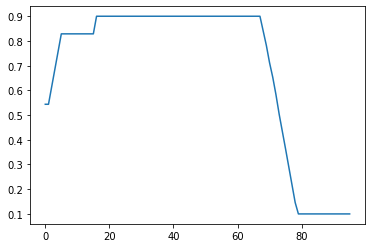

In [29]:
result.SoC_Bat.plot()

<Axes: >

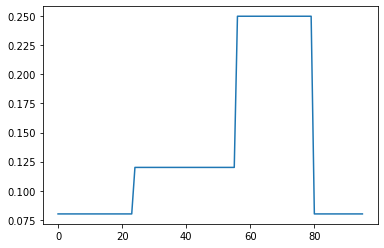

In [30]:
data['TOU'].plot()

<Axes: >

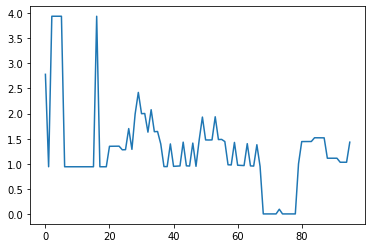

In [31]:
result.GridPurchase.plot()

In [22]:
result

,PV2Blgd,G2Blgd,Bat2Blgd,EV2Blgd,GridPurchase,PVcurt,PV2Bat,PV2EV,G2Bat,G2EV,Bat2EV,EV2Bat,SoC_Bat,SoC_EV
0,0.0,0.940000,0.0,0.0,0.940000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0
1,0.0,0.940000,0.0,0.0,0.940000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0
2,0.0,0.940000,0.0,0.0,0.940000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0
3,0.0,0.940000,0.0,0.0,0.940000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0
4,0.0,0.940000,0.0,0.0,0.940000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,0.0,1.110000,0.0,0.0,1.110000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0
92,0.0,1.030000,0.0,0.0,1.030000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0
93,0.0,1.030000,0.0,0.0,1.030000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0
94,0.0,1.030000,0.0,0.0,1.030000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0
